In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision.models.resnet import resnet18, ResNet18_Weights
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
from PIL import Image
import random
import numpy as np
from torchinfo import summary
from tqdm import tqdm


In [2]:
def get_gpu():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    else:
        return "cpu"
    
device = get_gpu()

### Завантаження датасету

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
class ButterflyMothDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        
        self.image_paths = list(self.root_dir.rglob("*.jpg"))
        
        self.classes = sorted(list(set(p.parent.name for p in self.image_paths)))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        image = Image.open(img_path).convert("RGB")
        
        label_name = img_path.parent.name
        label = self.class_to_idx[label_name]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize(256), 
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [6]:
train_dataset = ButterflyMothDataset("./data/train", transform=train_transforms)
test_dataset = ButterflyMothDataset("./data/test", transform=test_transforms)

train_dataset, test_dataset

(<__main__.ButterflyMothDataset at 0x107261fc0>,
 <__main__.ButterflyMothDataset at 0x107262e30>)

In [7]:
test_dataset.class_to_idx = train_dataset.class_to_idx
test_dataset.classes = train_dataset.classes

In [8]:
BATCH_SIZE = 128

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    generator=g
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    generator=g
)

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_random_images(dataset, n=5):
    plt.figure(figsize=(15, 5))
    
    classes = dataset.classes
    
    for i in range(n):
        idx = torch.randint(0, len(dataset), (1,)).item()
        image, label = dataset[idx]
        
        image = image.numpy().transpose((1, 2, 0))
        
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1) 
        
        plt.subplot(1, n, i + 1)
        plt.imshow(image)
        plt.title(f"Class: {classes[label]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


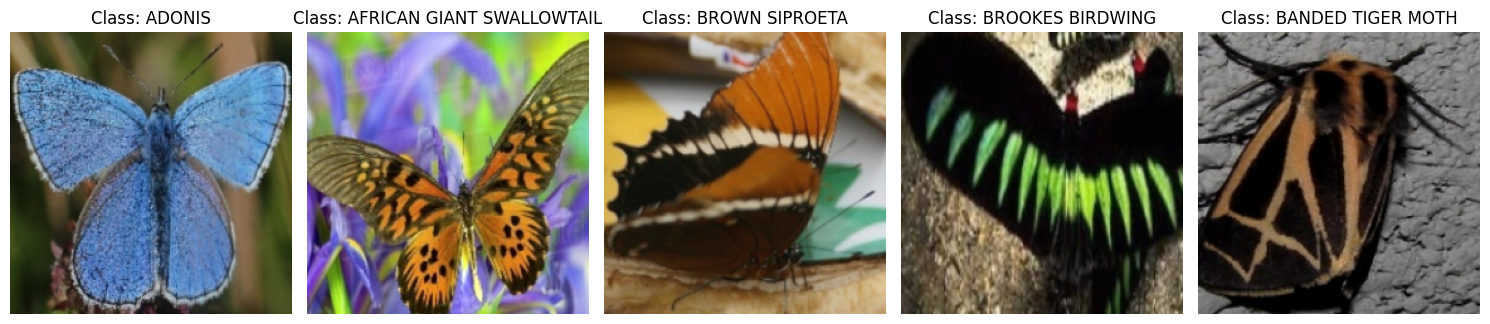

In [10]:
show_random_images(train_dataset, n=5)

### Створення власної архітектури

In [11]:
class Conv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0, stride=1, use_relu=True):
        super(Conv, self).__init__()

        self.use_relu = use_relu
        
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=padding,
            stride=stride
        )
        self.bn = nn.BatchNorm2d(num_features=out_channels)
        
        if use_relu:
            self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)

        if self.use_relu:
            x = self.relu(x)
            
        return x

In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, bottleneck_channels, out_channels):
        super().__init__()

        self.conv1 = Conv(
            in_channels=in_channels, 
            out_channels=bottleneck_channels,
            kernel_size=(1, 1)
        )
        self.conv2 = Conv(
            in_channels=bottleneck_channels,
            out_channels=bottleneck_channels,
            padding=1,
            kernel_size=(3, 3)
        )
        self.conv3 = Conv(
            in_channels=bottleneck_channels,
            out_channels=out_channels,
            kernel_size=(1, 1),
            use_relu=False
        )

        self.conv1x1 = nn.Conv2d(
            in_channels=in_channels, 
            out_channels=out_channels,
            kernel_size=(1, 1)
        )

        self.relu = nn.ReLU()

    def forward(self, X):
        identity = self.conv1x1(X)

        out = self.conv1(X)
        out = self.conv2(out)
        out = self.conv3(out)

        return self.relu(out + identity)

In [13]:
class ButterflyNet(nn.Module):
    def __init__(self, in_channels, out_features):
        super().__init__()

        self.initial_conv = nn.Conv2d(
            in_channels=in_channels, 
            out_channels=64, 
            kernel_size=(7, 7),
            stride=2,
            padding=3
        )

        self.max_pool = nn.MaxPool2d(kernel_size=(3, 3), stride=2, ceil_mode=True)

        self.avg_pool = nn.AvgPool2d(kernel_size=(2, 2), stride=2)

        self.block1 = ConvBlock(in_channels=64, bottleneck_channels=32, out_channels=128)
        
        self.block2 = ConvBlock(in_channels=128, bottleneck_channels=64, out_channels=256)
        self.block3 = ConvBlock(in_channels=256, bottleneck_channels=128, out_channels=512)

        self.adaptive_avg_pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))

        self.flatten = nn.Flatten()

        self.classifier = nn.Linear(in_features=512, out_features=out_features)

    def forward(self, X):
        X = self.max_pool(self.initial_conv(X))

        X = self.avg_pool(self.block1(X))
        X = self.avg_pool(self.block2(X))
        X = self.avg_pool(self.block3(X))

        X = self.flatten(self.adaptive_avg_pool(X))

        return self.classifier(X)


In [14]:
classes = len(train_dataset.classes)

classes

19

In [15]:
criterion = nn.CrossEntropyLoss()

def compute_loss(y_hat, y_true):
    
    return criterion(y_hat, y_true)

### Тренування власної архітектури

In [16]:
def train_model(
        model, optimizer, train_loader, valid_loader, 
        max_epochs=50, scheduler=None, early_stopping=None, model_name="model"
    ):
    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_acc": [],
        "valid_acc": []
    }
    
    n_epochs_without_impr = 0
    min_v_loss = float('inf')

    for epoch in range(max_epochs):
        model.train() 
        train_loss, train_correct, train_total = 0, 0, 0
        
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]", leave=False)
        
        for X_batch, y_batch in train_loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            l = compute_loss(logits, y_batch)

            optimizer.zero_grad() 
            l.backward()          
            optimizer.step()    

            train_loss += l.item()
            _, predicted = torch.max(logits.data, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()
            
            train_loop.set_postfix(loss=l.item())

        model.eval() 
        valid_loss, valid_correct, valid_total = 0, 0, 0
        
        with torch.no_grad():
            for X_valid, y_valid in valid_loader:
                X_valid, y_valid = X_valid.to(device), y_valid.to(device)

                v_logits = model(X_valid)
                v_l = compute_loss(v_logits, y_valid)

                valid_loss += v_l.item()
                _, v_predicted = torch.max(v_logits.data, 1)
                valid_total += y_valid.size(0)
                valid_correct += (v_predicted == y_valid).sum().item()

        t_loss = train_loss / len(train_loader)
        v_loss = valid_loss / len(valid_loader)
        t_acc = 100 * train_correct / train_total
        v_acc = 100 * valid_correct / valid_total

        print(f"Epoch [{epoch+1}/{max_epochs}] "
              f"| Train Loss: {t_loss:.4f}, Acc: {t_acc:.2f}% "
              f"| Valid Loss: {v_loss:.4f}, Acc: {v_acc:.2f}%")

        if scheduler is not None:
            scheduler.step(v_loss)

        history["train_loss"].append(t_loss)
        history["valid_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["valid_acc"].append(v_acc)

        if early_stopping is not None:
            if v_loss < min_v_loss:
                min_v_loss = v_loss
                n_epochs_without_impr = 0
                torch.save(model.state_dict(), f'{model_name}.pth')
                torch.save(history, f'{model_name}_results.pth')
            else:
                n_epochs_without_impr += 1
                print(f"--> No improvement for {n_epochs_without_impr} epochs.")
            
            if n_epochs_without_impr >= early_stopping:
                print(f"Early stopping triggered at epoch {epoch+1}")
                return history
              
    return history

In [29]:
def plot_compare_histories(hist_list, names):
    plt.figure(figsize=(16, 6))
    
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    plt.subplot(1, 2, 1)
    for i, (hist, name) in enumerate(zip(hist_list, names)):
        epochs = range(1, len(hist["train_loss"]) + 1)
        color = colors[i % len(colors)]
        
        plt.plot(epochs, hist["train_loss"], label=f"{name} (Train)", color=color, alpha=0.4)
        plt.plot(epochs, hist["valid_loss"], label=f"{name} (Valid)", color=color, linestyle='--')
        
        min_loss = min(hist["valid_loss"])
        plt.scatter(hist["valid_loss"].index(min_loss)+1, min_loss, color=color, s=30)

    plt.title("Loss Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    for i, (hist, name) in enumerate(zip(hist_list, names)):
        epochs = range(1, len(hist["train_acc"]) + 1)
        color = colors[i % len(colors)]
        
        plt.plot(epochs, hist["train_acc"], label=f"{name} (Train)", color=color, alpha=0.4)
        plt.plot(epochs, hist["valid_acc"], label=f"{name} (Valid)", color=color, linestyle='--')
        
        max_acc = max(hist["valid_acc"])
        plt.scatter(hist["valid_acc"].index(max_acc)+1, max_acc, color=color, s=30)

    plt.title("Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.ylim(None, 105)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [18]:
model = ButterflyNet(in_channels=3, out_features=classes).to(device)

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ButterflyNet                             [1, 19]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,472
├─MaxPool2d: 1-2                         [1, 64, 56, 56]           --
├─ConvBlock: 1-3                         [1, 128, 56, 56]          --
│    └─Conv2d: 2-1                       [1, 128, 56, 56]          8,320
│    └─Conv: 2-2                         [1, 32, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 32, 56, 56]           2,080
│    │    └─BatchNorm2d: 3-2             [1, 32, 56, 56]           64
│    │    └─ReLU: 3-3                    [1, 32, 56, 56]           --
│    └─Conv: 2-3                         [1, 32, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 32, 56, 56]           9,248
│    │    └─BatchNorm2d: 3-5             [1, 32, 56, 56]           64
│    │    └─ReLU: 3-6                    [1, 32, 56, 56]           --
│  

In [19]:
LEARNING_RATE = 0.001

model = ButterflyNet(in_channels=3, out_features=classes).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", 0.1, patience=4)

history = train_model(
    model, 
    optimizer, 
    train_loader, 
    test_loader, 
    max_epochs=50,
    scheduler=scheduler,
    early_stopping=10,
    model_name="own_model"
)

Epoch [1/50] | Train Loss: 2.0422, Acc: 37.83% | Valid Loss: 1.9145, Acc: 41.05%


Epoch [2/50] | Train Loss: 1.5072, Acc: 52.31% | Valid Loss: 1.7230, Acc: 45.26%


Epoch [3/50] | Train Loss: 1.2687, Acc: 60.30% | Valid Loss: 1.4486, Acc: 58.95%


Epoch [4/50] | Train Loss: 1.1161, Acc: 64.68% | Valid Loss: 1.4137, Acc: 51.58%


Epoch [5/50] | Train Loss: 1.0494, Acc: 68.41% | Valid Loss: 1.1210, Acc: 61.05%


...

Epoch [34/50] | Train Loss: 0.0982, Acc: 98.38% | Valid Loss: 0.1442, Acc: 95.79%
--> No improvement for 6 epochs.


Epoch [35/50] | Train Loss: 0.0797, Acc: 98.01% | Valid Loss: 0.1429, Acc: 93.68%
--> No improvement for 7 epochs.


Epoch [36/50] | Train Loss: 0.0908, Acc: 98.38% | Valid Loss: 0.1481, Acc: 92.63%
--> No improvement for 8 epochs.


Epoch [37/50] | Train Loss: 0.0803, Acc: 98.34% | Valid Loss: 0.1467, Acc: 93.68%
--> No improvement for 9 epochs.


Epoch [38/50] | Train Loss: 0.0787, Acc: 98.05% | Valid Loss: 0.1311, Acc: 93.68%
--> No improvement for 10 epochs.
Early stopping triggered at epoch 38


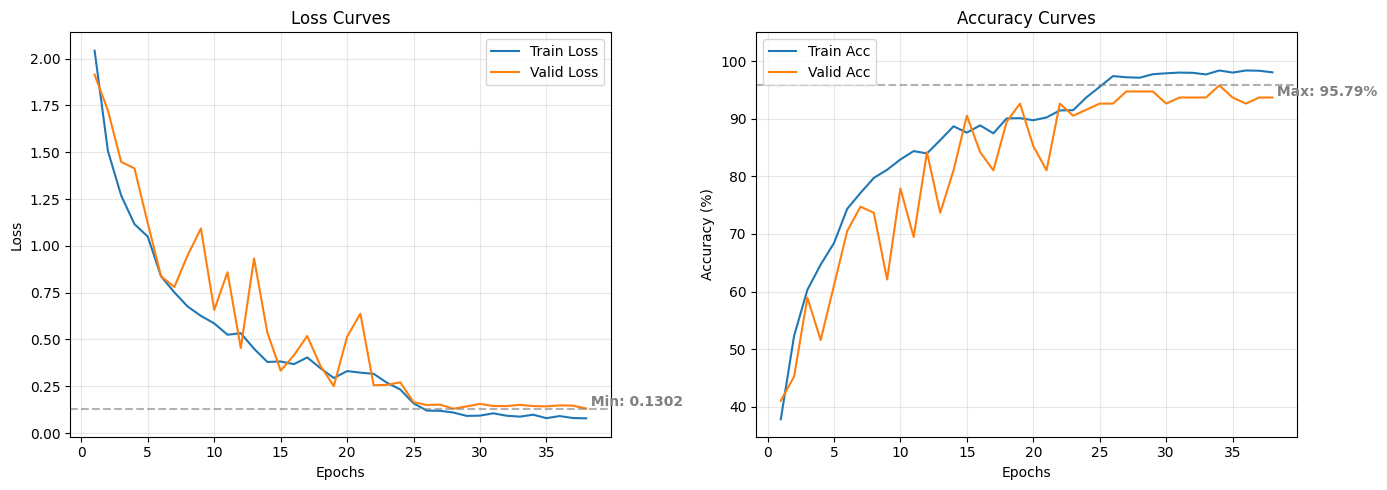

In [20]:
plot_history(history)

### Feature Extraction

In [21]:
pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)

summary(pretrained, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [22]:
for param in pretrained.parameters():
    param.requires_grad = False

In [23]:
LEARNING_RATE = 0.001

in_featuers = pretrained.fc.in_features
pretrained.fc = nn.Linear(in_features=in_featuers, out_features=classes)
pretrained.to(device)
optimizer = torch.optim.Adam(pretrained.fc.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", 0.1, patience=4)

history = train_model(
    pretrained, 
    optimizer, 
    train_loader, 
    test_loader, 
    max_epochs=35,
    scheduler=scheduler,
    early_stopping=5,
    model_name="feature_extracted"
)

Epoch [1/35] | Train Loss: 1.6365, Acc: 65.21% | Valid Loss: 0.5975, Acc: 91.58%


Epoch [2/35] | Train Loss: 0.5367, Acc: 92.98% | Valid Loss: 0.3122, Acc: 95.79%


Epoch [3/35] | Train Loss: 0.3473, Acc: 95.17% | Valid Loss: 0.2260, Acc: 96.84%


Epoch [4/35] | Train Loss: 0.2700, Acc: 95.50% | Valid Loss: 0.1788, Acc: 97.89%


Epoch [5/35] | Train Loss: 0.2331, Acc: 97.12% | Valid Loss: 0.1591, Acc: 96.84%


...

Epoch [31/35] | Train Loss: 0.0333, Acc: 99.39% | Valid Loss: 0.0319, Acc: 100.00%


Epoch [32/35] | Train Loss: 0.0306, Acc: 99.55% | Valid Loss: 0.0535, Acc: 98.95%
--> No improvement for 1 epochs.


Epoch [33/35] | Train Loss: 0.0352, Acc: 99.39% | Valid Loss: 0.0562, Acc: 97.89%
--> No improvement for 2 epochs.


Epoch [34/35] | Train Loss: 0.0406, Acc: 99.47% | Valid Loss: 0.0302, Acc: 98.95%


Epoch [35/35] | Train Loss: 0.0395, Acc: 99.03% | Valid Loss: 0.0429, Acc: 98.95%
--> No improvement for 1 epochs.


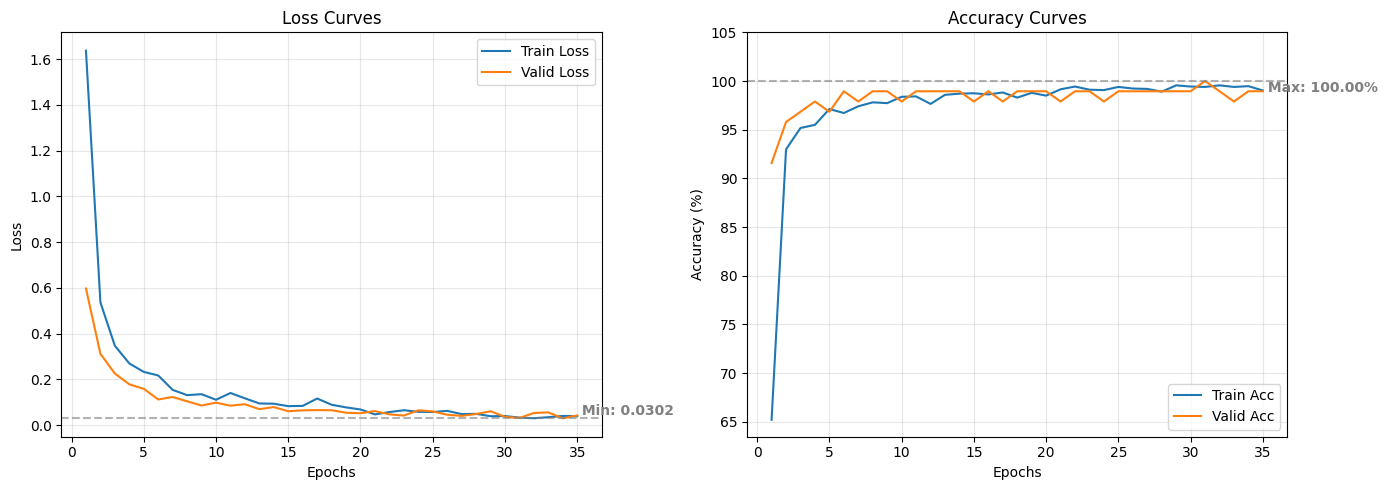

In [24]:
plot_history(history)

In [25]:
model_ft = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model_ft.parameters():
    param.requires_grad = False

for param in model_ft.layer4.parameters():
    param.requires_grad = True

num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, classes)

model_ft = model_ft.to(device)

params_to_update = [p for p in model_ft.parameters() if p.requires_grad]
optimizer_ft = torch.optim.Adam(params_to_update, lr=0.0001) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", 0.1, patience=4)

history = train_model(
    pretrained, 
    optimizer, 
    train_loader, 
    test_loader, 
    max_epochs=35,
    scheduler=scheduler,
    early_stopping=5,
    model_name="fine_tuned"
)

Epoch [1/35] | Train Loss: 0.0271, Acc: 99.72% | Valid Loss: 0.0396, Acc: 98.95%


Epoch [2/35] | Train Loss: 0.0274, Acc: 99.72% | Valid Loss: 0.0359, Acc: 98.95%


Epoch [3/35] | Train Loss: 0.0367, Acc: 99.47% | Valid Loss: 0.0407, Acc: 98.95%
--> No improvement for 1 epochs.


Epoch [4/35] | Train Loss: 0.0355, Acc: 99.27% | Valid Loss: 0.0260, Acc: 98.95%


Epoch [5/35] | Train Loss: 0.0374, Acc: 99.35% | Valid Loss: 0.0460, Acc: 98.95%
--> No improvement for 1 epochs.


Epoch [6/35] | Train Loss: 0.0907, Acc: 99.51% | Valid Loss: 0.0472, Acc: 97.89%
--> No improvement for 2 epochs.


Epoch [7/35] | Train Loss: 0.0487, Acc: 98.70% | Valid Loss: 0.0415, Acc: 98.95%
--> No improvement for 3 epochs.


Epoch [8/35] | Train Loss: 0.0411, Acc: 99.55% | Valid Loss: 0.0324, Acc: 98.95%
--> No improvement for 4 epochs.


Epoch [9/35] | Train Loss: 0.0363, Acc: 99.15% | Valid Loss: 0.0319, Acc: 98.95%
--> No improvement for 5 epochs.
Early stopping triggered at epoch 9


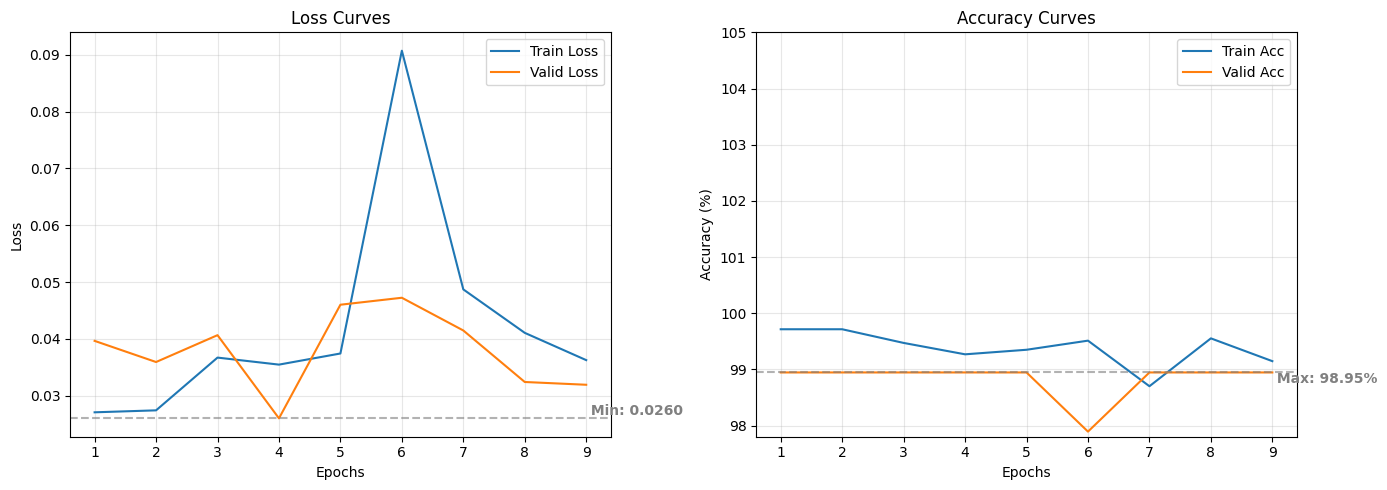

In [26]:
plot_history(history)

### Порівняння навчання моделей

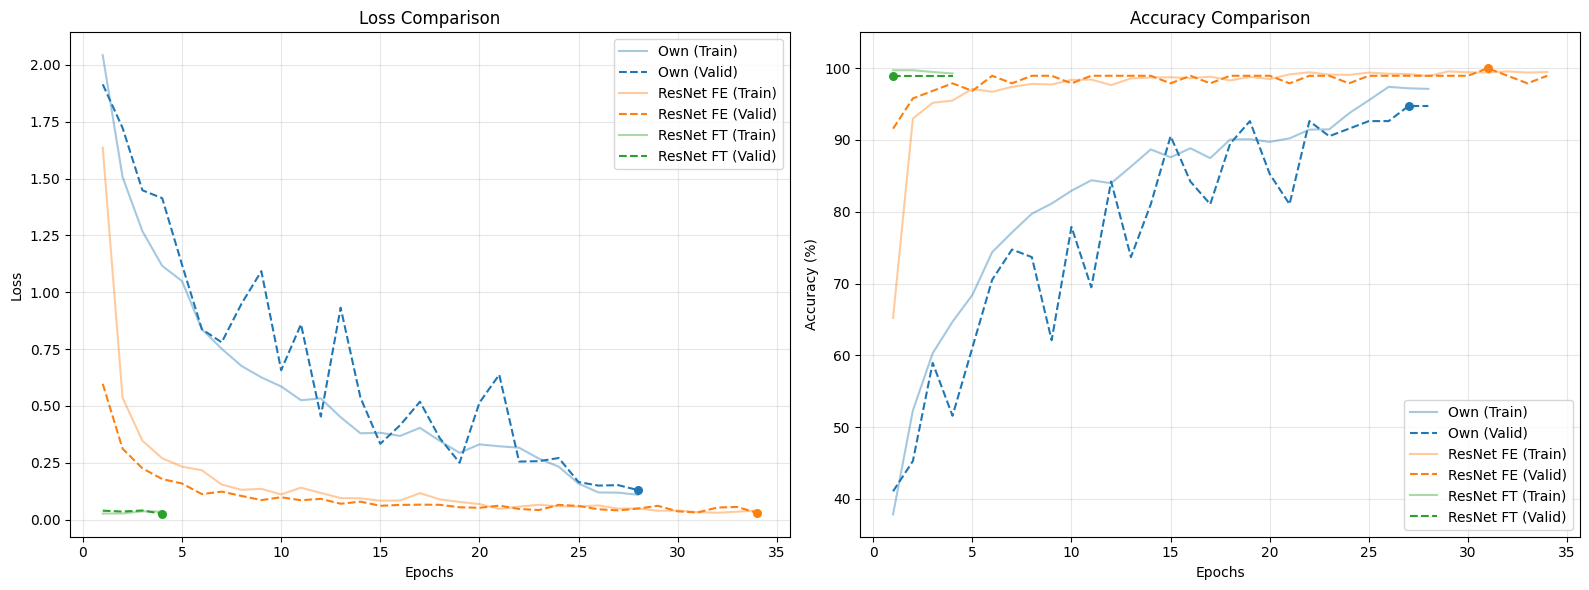

In [31]:
history_own = torch.load("own_model_results.pth")
history_fe = torch.load("feature_extracted_results.pth")
history_ft = torch.load("fine_tuned_results.pth")


plot_compare_histories([history_own, history_fe, history_ft], ["Own", "ResNet FE", "ResNet FT"])

### Тестування

In [27]:
def plot_confusion_matrix(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Final Test Set Confusion Matrix')
    plt.show()

    return cm

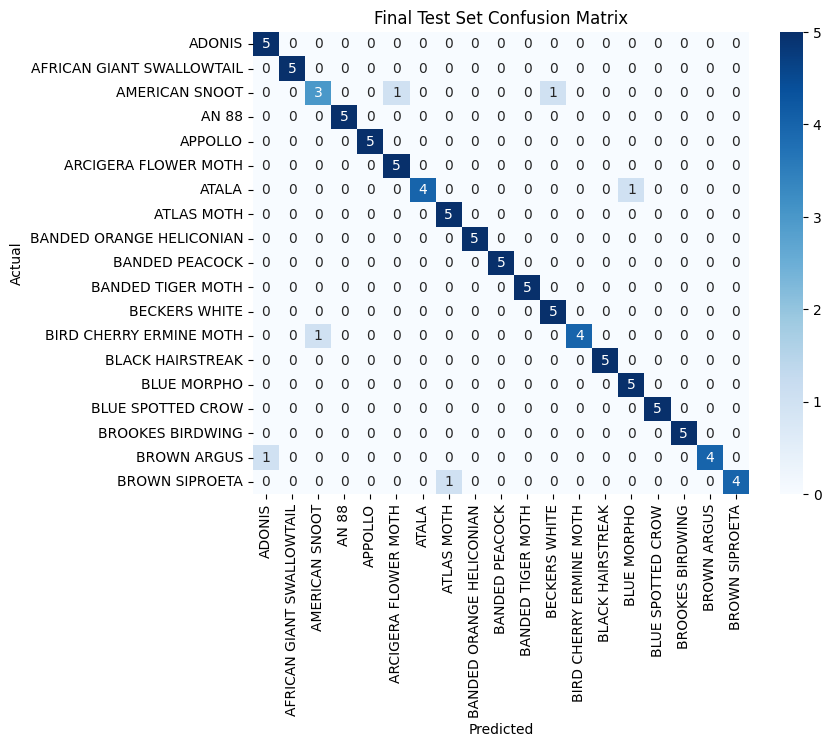

array([[5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0],
       [0,

In [28]:
plot_confusion_matrix(
    model, 
    test_loader, 
    device, 
    class_names=train_dataset.classes 
)

### Висновок

Фінальна модель демонструє високу точність, досягаючи 100% результату для 13 із 18 класів, що свідчить про успішну адаптацію ResNet18 до специфічних ознак метеликів. Найбільшу кількість помилок модель допускає у класі AMERICAN SNOOT (правильно визначено 3 з 5 зразків), плутаючи його з ARCIGERA FLOWER MOTH та BECKERS WHITE. Поодинокі випадки хибної класифікації також зафіксовані для класів BROWN ARGUS (плутанина з ADONIS) та BROWN SIPROETA (з ATLAS MOTH), проте відсутність системних збоїв та концентрація прогнозів на головній діагоналі підтверджують високу надійність моделі та її здатність до чіткої диференціації візуально схожих видів.